<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 5. RNN

## Настройка, установка и импорт необходимых библиотек

In [5]:
import re
import math

from collections import Counter

import requests
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Запущено на", "видеокарте" if torch.cuda.is_available() else "процессоре")

Запущено на процессоре


## Импорт и предобработка исходного корпуса

В качестве исходного текста использован роман-антиутопия Рея Бредбери «451 градус по Фаренгейту».

In [6]:
URL = "https://fantasy-worlds.org/lib/id13732/download/txt"

text = requests.get(URL).text

print("Количество символов:", len(text))

Количество символов: 273589


Небольшая предобработка и простая токенизация.

In [7]:
text = text.lower()

tokens = re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

print("Примеры токенов:", tokens[:50])
print("Количество токенов:", len(tokens))
print("Количество уникальных токенов:", len(set(tokens)))

Примеры токенов: ['annotation', '«', '451', '°', 'по', 'фаренгейту', '»', '—', 'роман', ',', 'принесший', 'писателю', 'мировую', 'известность', '.', '451', '°', 'по', 'фаренгейту', '—', 'температура', ',', 'при', 'которой', 'воспламеняется', 'и', 'горит', 'бумага', '.', 'философская', 'антиутопия', 'рэя', 'брэдбери', 'рисует', 'беспросветную', 'картину', 'развития', 'постиндустриального', 'общества', ';', 'это', 'мир', 'будущего', ',', 'в', 'котором', 'все', 'письменные', 'издания', 'безжалостно']
Количество токенов: 56030
Количество уникальных токенов: 11041


Ограничение количества используемых токенов и размера словаря, генерация числовых идентификаторов для токенов.

In [8]:
encode_token = lambda tok, stoi: stoi.get(tok, UNK_ID)

MULTIPLIER = 5
MAX_TOKENS = 100_000 * MULTIPLIER
MAX_VOCAB = 1000 * MULTIPLIER

tokens = tokens[:MAX_TOKENS]
print("Количество используемых токенов:", len(tokens))

cnt = Counter(tokens)
most_common = cnt.most_common(MAX_VOCAB - 2)

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

ids = [encode_token(t, stoi) for t in tokens]

k = 30

print("Размер словаря:", len(itos))
print(f"Первые {k} ID:", ids[:k])

Количество используемых токенов: 56030
Размер словаря: 5000
Первые 30 ID: [3745, 27, 792, 1476, 29, 1477, 28, 4, 2143, 2, 3746, 3747, 3748, 3749, 3, 792, 1476, 29, 1477, 4, 2144, 2, 288, 340, 2145, 5, 586, 1478, 3, 3750]


## Обучение модели

Разделение токенов на тренировочную и тестовую выборки.

In [9]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32


class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(
            self.ids[idx:idx + self.seq_len],
            dtype=torch.long,
        )
        y = torch.tensor(
            self.ids[idx + 1:idx + self.seq_len + 1],
            dtype=torch.long,
        )

        return x, y


split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Количество токенов в тренировочной выборке:", len(train_ids))
print("Количество токенов в тестовой выборке:", len(test_ids))
print("Количество текстов в тренировочной выборке:", len(train_dataset))
print("Количество текстов в тестовой выборке:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("Размерность xb:", xb.shape)
print("Размерность yb:", yb.shape)

Количество токенов в тренировочной выборке: 50427
Количество токенов в тестовой выборке: 5603
Количество текстов в тренировочной выборке: 50397
Количество текстов в тестовой выборке: 5573
Размерность xb: torch.Size([32, 30])
Размерность yb: torch.Size([32, 30])


Объявление класса исходной модели.

In [10]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        x = self.emb(x)
        h, h_n = self.rnn(x, h0)
        logits = self.out(h)

        return logits, h_n

Первоначальная проверка модели.

In [11]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("Размерность логитов:", logits.shape)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("Loss:", float(loss))

Размерность логитов: torch.Size([32, 30, 5000])
Loss: 8.514955520629883


/tmp/ipykernel_1143/674787657.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss:", float(loss))


Обучение модели.

In [12]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    total_loss = 0.0
    total_batches = 0

    model.eval()

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)

    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    running_loss = 0.0

    model.train()

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(
        model,
        test_loader,
        criterion,
        device,
        VOCAB_SIZE,
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch + 1:2d}/{EPOCHS} | "
        f"Train loss = {train_loss:.4f} | Train PPL = {train_ppl:.2f} | "
        f"Test loss = {test_loss:.4f} | Test PPL = {test_ppl:.2f}"
    )

Epoch  1/10 | Train loss = 7.3240 | Train PPL = 1516.20 | Test loss = 6.1701 | Test PPL = 478.25
Epoch  2/10 | Train loss = 5.9188 | Train PPL = 371.96 | Test loss = 5.7515 | Test PPL = 314.67
Epoch  3/10 | Train loss = 5.7739 | Train PPL = 321.79 | Test loss = 5.7044 | Test PPL = 300.18
Epoch  4/10 | Train loss = 5.7185 | Train PPL = 304.46 | Test loss = 5.6758 | Test PPL = 291.73
Epoch  5/10 | Train loss = 5.6657 | Train PPL = 288.80 | Test loss = 5.6478 | Test PPL = 283.68
Epoch  6/10 | Train loss = 5.6136 | Train PPL = 274.12 | Test loss = 5.6249 | Test PPL = 277.23
Epoch  7/10 | Train loss = 5.5636 | Train PPL = 260.76 | Test loss = 5.6077 | Test PPL = 272.52
Epoch  8/10 | Train loss = 5.5175 | Train PPL = 249.00 | Test loss = 5.5933 | Test PPL = 268.61
Epoch  9/10 | Train loss = 5.4708 | Train PPL = 237.64 | Test loss = 5.5755 | Test PPL = 263.88
Epoch 10/10 | Train loss = 5.4233 | Train PPL = 226.63 | Test loss = 5.5624 | Test PPL = 260.45


## График training loss

График лоса на обучающей выборке. С увеличением количества эпох лос уменьшается. Самый большой разрыв – между первой и второй эпохой, далее лос линейно уменьшается с увеличением числа эпох.

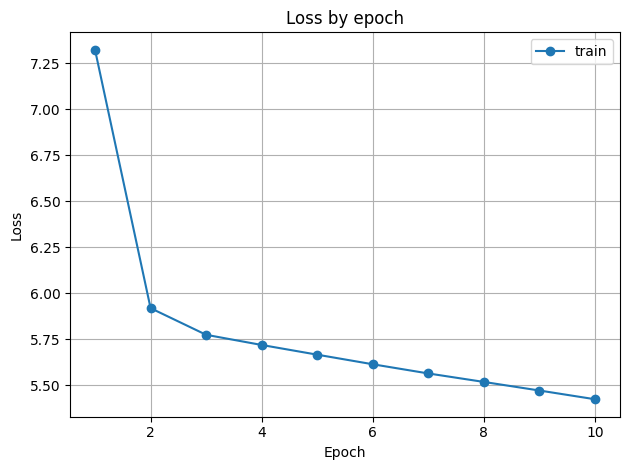

In [13]:
plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="train",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss by epoch")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Генерация текста и сравнение результатов

Вспомогательные функции для генерации текста.

In [14]:
def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    logits = logits / temperature

    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()

        return int(indices[chosen].item())

    probs = torch.softmax(logits, dim=0)

    return int(torch.multinomial(probs, num_samples=1).item())


@torch.no_grad()
def generate_text(
    model,
    prompt,
    stoi,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None,
):
    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)

    model.eval()

    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization")

    input_ids = [stoi.get(t, UNK_ID) for t in prompt_tokens]
    generated = input_ids[:]

    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k,
        )

        generated.append(next_id)

        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated, itos)


decode_ids = lambda id_list, itos: " ".join(itos[i] for i in id_list)

Сгенерировав текст 4 способами можно заметить следующее:

1. Greedy выбирает самый вероятный токен на каждом шаге. Модель быстро застревает в петле ",- \<unk\>", потому что жадный выбор всегда ведёт к одному и тому же следующему токену;
2. Sampling – случайный выбор из всего распределения вероятностей. Текст разнообразный, без зацикливания, но бессвязный и грамматически ломаный. Модель «прыгает» между маловероятными словами;
3. Sampling with temperature – температура сглаживает или заостряет распределение. При температуре 0.5 текст ближе к greedy: снова появляются повторы \<unk\>, но с чуть большим разнообразием;
4. Sampling with top-k делает выбор только из k самых вероятных токенов. Даёт лучший баланс: текст более связный, нет зацикливания и фразы не идеальны, но выглядят наиболее «человечно» из всех четырёх вариантов;

Общая проблема – обилие \<unk\> во всех вариантах. Это значит, что большая часть словаря русского текста не попала в MAX_VOCAB, и модели не хватает словарного запаса. Русский язык морфологически богаче английского (падежи, спряжения, приставки), поэтому уникальных словоформ значительно больше. Для улучшения стоит увеличить MAX_VOCAB или перейти на посимвольную/BPE-токенизацию.

In [15]:
prompt = "сжигать книги"

print("Greedy:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="greedy"), "\n")
print("Sampling:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling"), "\n")
print("Sampling with temperature:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling", temperature=0.5), "\n")
print("Sampling with top-k:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling", top_k=10), "\n")

Greedy:
 сжигать книги , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , — <unk> , 

Sampling:
 сжигать книги весь минуту <unk> послушно вдруг нога того , остановился . — <unk> голову . надо , сидела скорее ? что да с таблетки бежал шикарно с скорее и снова нужна шел чем <unk> на черту сошел окном <unk> <unk> на 

Sampling with temperature:
 сжигать книги , <unk> <unk> , и <unk> , и <unk> , — я <unk> . и я <unk> , <unk> и <unk> . — он <unk> , — <unk> <unk> . — я к <unk> , <unk> <unk> . — <unk> 

Sampling with top-k:
 сжигать книги , а это не , что я не и <unk> . — он <unk> . , а <unk> , и <unk> , не . <unk> . что он <unk> <unk> ! . он <unk> . <unk> . , <unk> , 



## Генерация текста с помощью LSTM

Объявления класса исходной модели.

In [16]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        h, state = self.lstm(x, state)
        logits = self.out(h)

        return logits, state

Первоначальная проверка.

In [17]:
model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

xb, yb = next(iter(train_loader))

xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("Размерность логитов:", logits.shape)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("Loss:", float(loss))

Размерность логитов: torch.Size([32, 30, 5000])
Loss: 8.5562744140625


Обучение модели.

In [18]:
EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    running_loss = 0.0

    model.train()

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(
        model,
        test_loader,
        criterion,
        device,
        VOCAB_SIZE,
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch + 1:2d}/{EPOCHS} | "
        f"Train loss = {train_loss:.4f} | Train PPL = {train_ppl:.2f} | "
        f"Test loss = {test_loss:.4f} | Test PPL = {test_ppl:.2f}"
    )

Epoch  1/10 | Train loss = 7.3811 | Train PPL = 1605.38 | Test loss = 6.2419 | Test PPL = 513.82
Epoch  2/10 | Train loss = 5.9642 | Train PPL = 389.25 | Test loss = 5.7864 | Test PPL = 325.85
Epoch  3/10 | Train loss = 5.8160 | Train PPL = 335.63 | Test loss = 5.7678 | Test PPL = 319.82
Epoch  4/10 | Train loss = 5.7987 | Train PPL = 329.86 | Test loss = 5.7748 | Test PPL = 322.09
Epoch  5/10 | Train loss = 5.7817 | Train PPL = 324.32 | Test loss = 5.7780 | Test PPL = 323.11
Epoch  6/10 | Train loss = 5.7588 | Train PPL = 316.96 | Test loss = 5.7730 | Test PPL = 321.51
Epoch  7/10 | Train loss = 5.7294 | Train PPL = 307.79 | Test loss = 5.7635 | Test PPL = 318.47
Epoch  8/10 | Train loss = 5.6931 | Train PPL = 296.80 | Test loss = 5.7400 | Test PPL = 311.08
Epoch  9/10 | Train loss = 5.6449 | Train PPL = 282.85 | Test loss = 5.7106 | Test PPL = 302.04
Epoch 10/10 | Train loss = 5.5897 | Train PPL = 267.65 | Test loss = 5.6849 | Test PPL = 294.40


Модель быстро учится базовым паттернам в первые эпохи, но затем «упирается в потолок». Финальная перплексия ~300 означает, что модель в среднем «выбирает» из ~300 равновероятных слов на каждом шаге — это довольно много и объясняет низкое качество генерации.

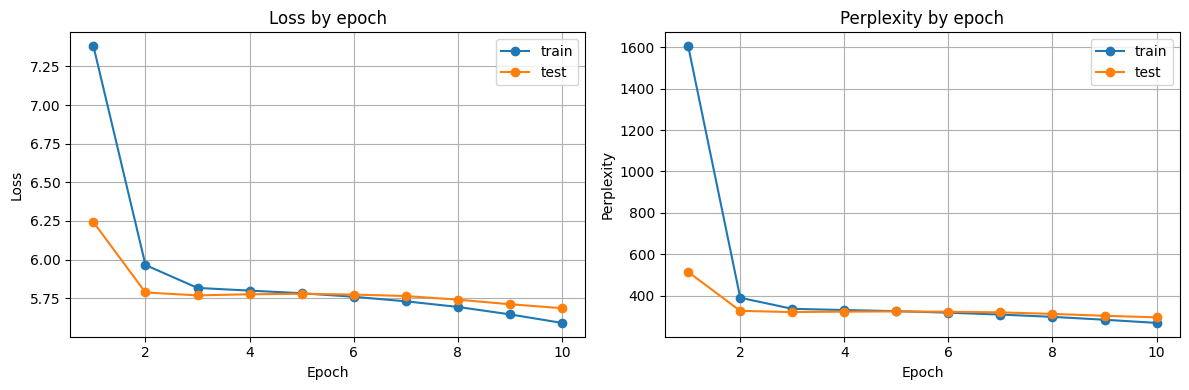

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

В целом, сгенерированные предложения получились похожими на те, что были получены при генерации с RNN. Чтобы увидеть разницу между RNN и LSTM, нужно увеличить размерности и MAX_VOCAB.

In [20]:
prompt = "сжигать книги"

print("Greedy:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="greedy"), "\n")
print("Sampling:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling"), "\n")
print("Sampling with temperature:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling", temperature=0.5), "\n")
print("Sampling with top-k:\n", generate_text(model, prompt, stoi, max_new_tokens=40, method="sampling", top_k=10), "\n")

Greedy:
 сжигать книги , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> , <unk> 

Sampling:
 сжигать книги с скажешь будут и быть . теперь — не заметили только любопытство заткнуты в о то , же хотят сейчас <unk> <unk> , … радио эту водой наконец » истуканы ее того ! подошел , от вас <unk> , может 

Sampling with temperature:
 сжигать книги , <unk> . и <unk> , его <unk> , не <unk> . <unk> . — . — <unk> , , <unk> . . — , — <unk> , <unk> , <unk> , — <unk> . — . — — , 

Sampling with top-k:
 сжигать книги , что <unk> , что и <unk> . <unk> и <unk> , <unk> . <unk> , <unk> , <unk> , — . <unk> <unk> . — . и — , не <unk> в <unk> не что . — . — 

